# Подбор порога амплитуды (Чуа, manuscript_chua_2)

Амплитуда совпадает с полем в `calculate_dynamic_regime`: $\|\mathrm{ptp}(X)\|_2$ по точкам сечения Пуанкаре $S(x)=y$ (пересечения $S<0 \to S\ge 0$), после `n_transient` пересечений.

Траектории с **амплитудой $\ge$ порога** интерпретируем как попадание на **крупный** предельный цикл и выкидываем при обучении (`train_exclude_large_lc.py`). Порог переносите в `REJECT_AMPLITUDE_ABOVE` в `e2_chua_config.py`.


In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

def _find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for _ in range(10):
        if (p / "systems" / "chua_rk4.py").exists():
            return p
        if p.parent == p:
            break
        p = p.parent
    raise FileNotFoundError(
        "Не найден корень репозитория. Запустите ноутбук с cwd в neuromap_sync или в experiments/manuscript_chua_2."
    )


_REPO = _find_repo_root(Path.cwd())
_M = _REPO / "experiments" / "manuscript_chua_2"
for _p in (_REPO, _M):
    s = str(_p)
    if s not in sys.path:
        sys.path.insert(0, s)

from e2_chua_config import (
    SEED,
    VARIABLES_RANGES,
    PARAMETERS_RANGES,
    DT,
    N_TRANSIENT,
)
from systems.chua_rk4 import chua_rk4, chua_right_part
from utils.trajectories import calculate_dynamic_regime


In [6]:
n_var = len(VARIABLES_RANGES)
n_param = len(PARAMETERS_RANGES)


def secant_plane(state, params):
    _ = params
    return float(state[1])


def secant_plane_derivatives(state, params):
    _ = state, params
    return np.array([0.0, 1.0, 0.0], dtype=np.float64)


def one_sample(i):
    rg = np.random.default_rng(SEED + 1_000_003 * int(i))
    x0 = rg.uniform(
        [r[0] for r in VARIABLES_RANGES],
        [r[1] for r in VARIABLES_RANGES],
    )
    p0 = rg.uniform(
        [r[0] for r in PARAMETERS_RANGES],
        [r[1] for r in PARAMETERS_RANGES],
    )
    reg = calculate_dynamic_regime(
        chua_rk4,
        chua_right_part,
        x0,
        p0,
        DT,
        N_TRANSIENT,
        n_attractor=100,
        secant_plane=secant_plane,
        secant_plane_derivatives=secant_plane_derivatives,
        accuracy=1e-3,
        max_steps=100_000,
        fixed_point_threshold=1e-12,
        divergence_threshold=1e5,
    )
    return reg | {"x0": x0, "p0": p0}

Увеличьте `n_samples` и при необходимости `n_jobs`, если разделение режимов по амплитуде должно быть устойчивее.


In [7]:
n_samples = 800
n_jobs = -1

rows = Parallel(n_jobs=n_jobs, backend="loky")(delayed(one_sample)(i) for i in range(n_samples))

types = np.array([r["type"] for r in rows])
amps = np.array([r.get("amplitude") for r in rows], dtype=object)
mask_fin = np.array([a is not None for a in amps], dtype=bool)
amps_num = np.array([float(a) if a is not None else np.nan for a in amps])

print("режимы:", {t: int(np.sum(types == t)) for t in np.unique(types)})
print("конечная амплитуда:", int(mask_fin.sum()), "/", n_samples)

режимы: {np.str_('D'): 726, np.str_('NP'): 49, np.str_('P'): 25}
конечная амплитуда: 74 / 800


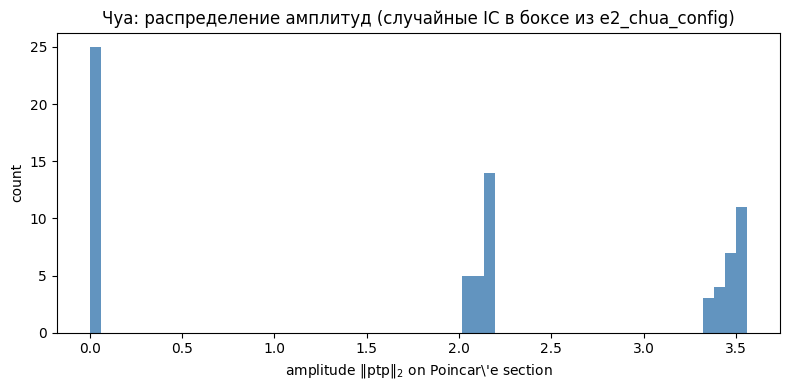

In [10]:
a = amps_num[np.isfinite(amps_num)]
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(a, bins=60, color="steelblue", alpha=0.85)
ax.set_xlabel(r"amplitude $\|\mathrm{ptp}\|_2$ on Poincar\'e section")
ax.set_ylabel("count")
ax.set_title("Чуа: распределение амплитуд (случайные IC в боксе из e2_chua_config)")

plt.tight_layout()
plt.show()